# CSCI 443 HW 7: ANOVA, Chi-Square, Complexity Analysis

## Part 1: Permutation ANOVA: Does Debugging Snack Affect Completion Time?

A professor wants to know whether the snack given during lab affects how long students take to fix a buggy program.

The file `debugging_snacks.csv` contains simulated completion times for four snack groups:

- No snack
- Trail mix
- Energy bar
- Gummy worms

**1.1.** Load the CSV file and compute the mean, median, and standard deviation of completion time for each snack group.

**1.2.** Create a boxplot for each group.  Do any of the groups look skewed?  Why?  Do these look Gaussian?

**1.3.** State the null and alternative hypotheses for a one-way ANOVA.

**1.4.** Explain why a permutation ANOVA is more appropriate than relying only on classical ANOVA assumptions.

**1.5.** Compute the observed ANOVA F-statistic.

**1.6.** Perform a permutation ANOVA by repeatedly shuffling the snack labels while keeping the completion times fixed.

**1.7.** Estimate the p-value:

   \[
   p = \frac{\text{number of permuted F-statistics at least as large as observed F}}{\text{number of permutations}}
   \]

**1.8.** At α = 0.05, determine whether to reject the null hypothesis.

**1.9.** Briefly interpret the result.

                  mean  median        std
snack                                    
Energy bar   51.995867   46.28  19.755798
Gummy worms  50.237600   45.94  26.233364
No snack     51.941733   52.26   6.679851
Trail mix    48.422667   47.75   9.673531


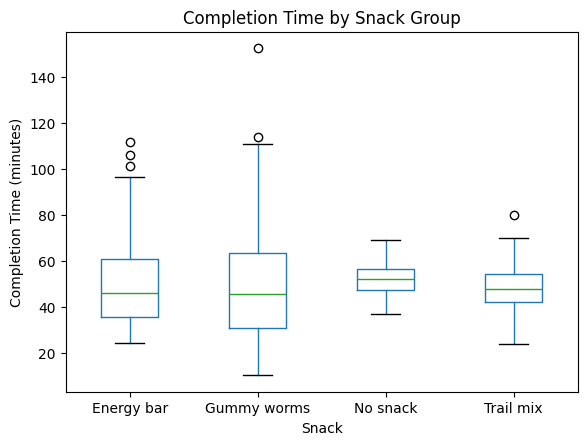

Observed F: 0.7077480361263782
Permutation p-value: 0.5512
Fail to reject H0


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("debugging_snacks.csv")

print(df.groupby("snack")["completion_time_minutes"].agg(["mean", "median", "std"]))

df.boxplot(column="completion_time_minutes", by="snack", grid=False)
plt.title("Completion Time by Snack Group")
plt.suptitle("")
plt.xlabel("Snack")
plt.ylabel("Completion Time (minutes)")
plt.show()

groups = [g["completion_time_minutes"].to_numpy() for _, g in df.groupby("snack")]
vals = df["completion_time_minutes"].to_numpy()
k, N = len(groups), len(vals)
grand = vals.mean()

ssb = sum(len(g) * (g.mean() - grand)**2 for g in groups)
ssw = sum(((g - g.mean())**2).sum() for g in groups)
F_obs = (ssb/(k-1)) / (ssw/(N-k))
print("Observed F:", F_obs)

rng = np.random.default_rng(443)
labels = df["snack"].to_numpy(dtype=object)
F_perm = np.empty(10000)

for i in range(10000):
    shuffled = labels.copy()
    rng.shuffle(shuffled)
    temp = df.copy()
    temp["snack"] = shuffled
    gs = [g["completion_time_minutes"].to_numpy() for _, g in temp.groupby("snack")]
    ssb_p = sum(len(g) * (g.mean() - grand)**2 for g in gs)
    ssw_p = sum(((g - g.mean())**2).sum() for g in gs)
    F_perm[i] = (ssb_p/(k-1)) / (ssw_p/(N-k))

p_value = np.mean(F_perm >= F_obs)
print("Permutation p-value:", p_value)

print("Reject H0" if p_value < 0.05 else "Fail to reject H0")

Answers:\
1.2: energy bar and gummy worms are skewed to the right because they have a wider spread and high outliers. The groups don't look Gaussian.\
1.3: Null hypothesis H_0: the mean completion time is the same for all  groups. Alternative hypothesis H_A: At least one  group has a different mean completion time.\
1.4: It doesn't rely as much on equal-variance assumptions. permutation builds the p-value by shuffling snack labels and comparing the f-statistic to that shuffled distribution.\
1.8: 0.55 > 0.05, so we fail to reject H_0.\
1.9: There isn't enough evidence to conclude that the snack type changes average completion time in this dataset. The differences in the means are consistent with random variation under the null model.

## Part 2: Chi-Square - Caffeine and Coding Style

A professor suspects that preferred caffeinated beverage and preferred programming style are independent. A survey of students asked which drink they prefer among those listed and their preferred coding style produced the following observed counts:

| Beverage                     | Functional | Object-Oriented | Just Make It Work | Total |
|-----------------------------|-----------:|----------------:|------------------:|------:|
| Black coffee / espresso     | 24         | 10              | 6                 | 40    |
| Latte                       | 8          | 28              | 14                | 50    |
| Foo Bar Energy drink        | 8          | 7               | 25                | 40    |
| **Total**                   | **40**     | **45**          | **45**            | **130** |

**2.1.** State the null and alternative hypotheses.

**2.2.** Compute the expected count for each cell:

   \[
   E_{ij} = \frac{(\text{row total})(\text{column total})}{\text{grand total}}
   \]

Create a new cell by copying and pasting from the one above and adding the expected values
in parenthesis to each cell.

**2.3.** Compute the chi-squared statistic:

   \[
   \chi^2 = \sum \frac{(O - E)^2}{E}
   \]

**2.4.** Compute the degrees of freedom.

**2.5.** At α = 0.05, determine whether to reject the null hypothesis.

**2.6.** Briefly interpret the result. Which beverage/coding-style pair contributes most strongly to the result?

In [17]:
import numpy as np

O = np.array([
    [24, 10,  6],
    [ 8, 28, 14],
    [ 8,  7, 25]
], dtype=float)

row_tot = O.sum(axis=1, keepdims=True)
col_tot = O.sum(axis=0, keepdims=True)
N = O.sum()
E = row_tot @ col_tot / N

chi2 = ((O - E)**2 / E).sum()
df = (O.shape[0]-1) * (O.shape[1]-1)

contrib = (O - E)**2 / E
i, j = np.unravel_index(np.argmax(contrib), contrib.shape)
labels_rows = ["Black coffee/espresso", "Latte", "Foo Bar Energy drink"]
labels_cols = ["Functional", "Object-Oriented", "Just Make It Work"]

print("Expected counts:\n", np.round(E, 2))
print("Chi-square:", round(chi2, 4))
print("df:", df)
print("Largest contributor:", labels_rows[i], "+", labels_cols[j])

Expected counts:
 [[12.31 13.85 13.85]
 [15.38 17.31 17.31]
 [12.31 13.85 13.85]]
Chi-square: 41.2822
df: 4
Largest contributor: Black coffee/espresso + Functional


Answers:\
2.1: H_0: beverage preference and coding style are independent. H_A: beverage preference and coding style are not independent.\
2.2:
| Beverage                     | Functional | Object-Oriented | Just Make It Work | Total |
|-----------------------------|-----------:|----------------:|------------------:|------:|
| Black coffee / espresso     | 24 (12.31) | 10 (13.85)      | 6 (13.85)         | 40    |
| Latte                       | 8  (15.38) | 28 (17.31)      | 14 (17.31)        | 50    |
| Foo Bar Energy drink        | 8  (12.31) | 7  (13.85)      | 25 (13.85)        | 40    |
| **Total**                   | **40**     | **45**          | **45**            | **130** |

2.5: 41.28 > 9.488, so reject the null hypothesis.\
2.6: beverage preference and coding style are associated, not independent. The strongest contributing pair is black coffee/espresso and functional.

## Part 3: Spark Performance Analysis: Distributed Bloom Filter

We have recently hired a physics professor who studied under Stephen Hawking. 
He suspects that a few students in the class are actually time travelers 
who have enrolled multiple times across different centuries at different
universities around the world.

He has compiled a large database of prior students from the United States,
the United Kingdom, and many other European countries.

The dataset contains `n` records of prior students distributed across 
`p` Spark partitions. We want to build a Bloom filter so that later queries can test whether newly enrolled students were probably present in the original dataset. If a student is reported as probably present, we will investigate further.

We use a Bloom filter because it supports cheap approximate membership 
queries. It may produce false positives, but it should not produce false
negatives under the standard insert-only model.  If we find a 
possible positive, we will investigate further to determine the veracity
of the match.

The Bloom filter has:

- `m` bits

- `k` hash functions

Each partition builds a local Bloom filter. The local Bloom filters are then combined using bitwise OR through a tree-reduction.

**3.1.** Read about Bloom filters and explain what a Bloom filter guarantees:

- What kind of error is possible?

- What kind of error is not possible?

**3.2.** Analyze executor time complexity.

**3.3.** Analyze executor memory complexity.

**3.4.** Analyze driver time complexity.

**3.5.** Analyze driver memory complexity.

**3.6.** Analyze total work.

**3.7.** Analyze network volume.

**3.8.** How many full-data shuffles are required?

**3.9.** How many actions are required?

**3.10.** Could you perform exact membership queries by first sorting the entire dataset? Compare using a Bloom filter with sorting the full dataset. How do the time and space costs compare for the executor and driver? What is gained, and what is lost?


answers:
3.1: bloom filter can give false positives, but no false negatives.
3.2: O(nk/p)
3.3: O(m)
3.4: O(mp)
3.5: O(m)
3.6: O(nk+mp)
3.7: O(mp) bits
3.8: none
3.9: 1
3.10: Yes it's possible, but it costs much more. Bloom filter has lower executor/driver time and memory than but sorting gives exact membership.  Bloom filter has faster speed and lower cost but has no exactness.
